In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
thresholds = ['[ 0, 8 ]', '[ 0, 7 ]', '[ 0, 6 ]', '[ 0, 5 ]']

baseline = np.array([86.22, 89.06, 89.4, 85.7])
traditional = np.array([95.84, 97.05, 95.65, 95.61])
generative = np.array([98.86, 98.75, 98.86, 98.51])

x = np.arange(len(thresholds))
t_gain = traditional - baseline
g_gain = generative - baseline

In [13]:
from matplotlib.colors import LinearSegmentedColormap

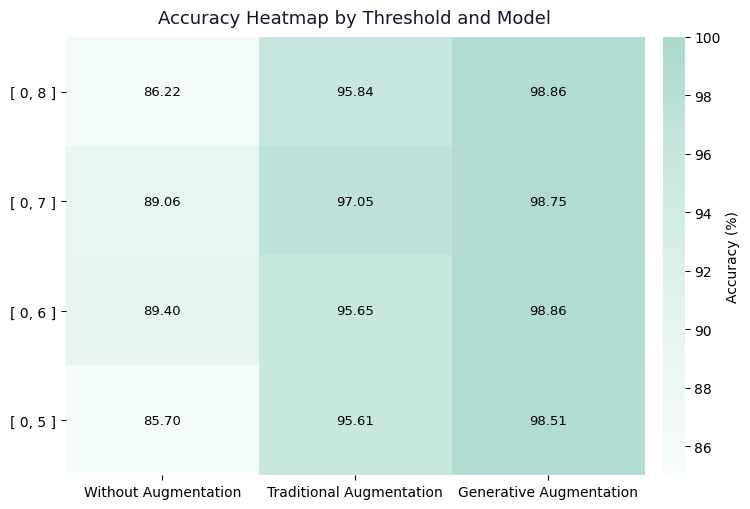

In [14]:
models = ['Without Augmentation', 'Traditional Augmentation', 'Generative Augmentation']

matrix = np.array([
    [86.22, 95.84, 98.86],
    [89.06, 97.05, 98.75],
    [89.4, 95.65, 98.86],
    [85.7, 95.61, 98.51],
])


light_cmap = LinearSegmentedColormap.from_list(
    'light_teal',
    ['#F7FCFD', '#EAF7F4', '#D9EFE9', '#C5E6DE', '#A9D8CC']
 )

fig, ax = plt.subplots(figsize=(7.6, 5.2))

im = ax.imshow(matrix, cmap=light_cmap, aspect='auto', vmin=85, vmax=100)

ax.set_xticks(np.arange(len(models)))
ax.set_yticks(np.arange(len(thresholds)))
ax.set_xticklabels(models, fontsize=10)
ax.set_yticklabels(thresholds, fontsize=10)
ax.set_title('Accuracy Heatmap by Threshold and Model', fontsize=13, color="#0F172A", pad=10)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = matrix[i, j]
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=9.5)

cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label('Accuracy (%)', rotation=90)
cbar.outline.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

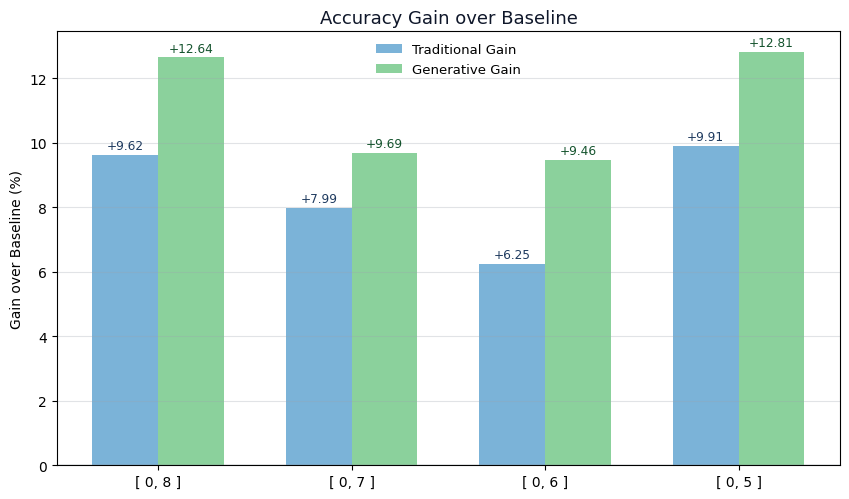

In [15]:
# accuracy gain over baseline
fig, ax = plt.subplots(figsize=(8.6, 5.1))
bar_w = 0.34
ax.bar(x - bar_w / 2, t_gain, width=bar_w, color="#7BB3D8", label='Traditional Gain')
ax.bar(x + bar_w / 2, g_gain, width=bar_w, color="#8BD19C", label='Generative Gain')

for i, v in enumerate(t_gain):
    ax.text(i - bar_w / 2, v + 0.08, f"+{v:.2f}", ha='center', va='bottom', fontsize=8.7, color="#1E3A5F")
for i, v in enumerate(g_gain):
    ax.text(i + bar_w / 2, v + 0.08, f"+{v:.2f}", ha='center', va='bottom', fontsize=8.7, color="#14532D")

ax.axhline(0, color="#9CA3AF", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.set_ylabel('Gain over Baseline (%)')
ax.set_title('Accuracy Gain over Baseline', fontsize=13, color="#0F172A")
ax.grid(axis='y', alpha=0.30, color="#9CA3AF")
ax.legend(frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()

/var/folders/y6/v08pgd9n6f32p2hsb0h872_h0000gn/T/ipykernel_5643/2031393400.py:90: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0.06, 0.08, 1.0, 0], h_pad=3.2, w_pad=2.4)


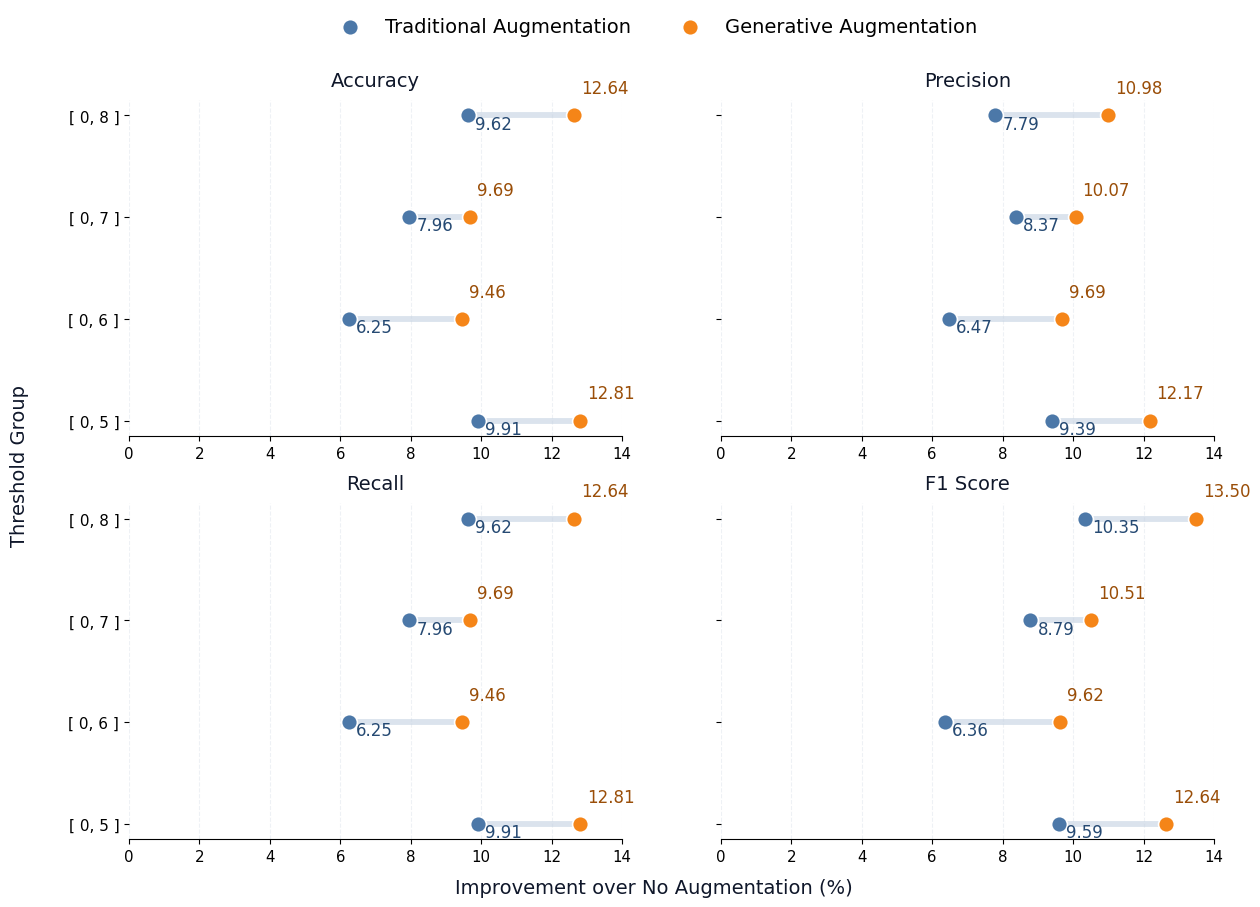

In [16]:
x = np.arange(len(thresholds))

# baseline
base_acc = np.array([86.22, 89.06, 89.40, 85.70])
base_prec = np.array([87.89, 88.69, 89.17, 86.34])
base_rec = np.array([86.22, 89.06, 89.40, 85.70])
base_f1 = np.array([85.34, 88.25, 89.24, 85.87])

# traditional
trad_acc_raw = np.array([95.84, 97.02, 95.65, 95.61])
trad_prec_raw = np.array([95.68, 97.06, 95.64, 95.73])
trad_rec_raw = np.array([95.84, 97.02, 95.65, 95.61])
trad_f1_raw = np.array([95.69, 97.04, 95.60, 95.46])

# generative
gen_acc_raw = np.array([98.86, 98.75, 98.86, 98.51])
gen_prec_raw = np.array([98.87, 98.76, 98.86, 98.51])
gen_rec_raw = np.array([98.86, 98.75, 98.86, 98.51])
gen_f1_raw = np.array([98.84, 98.76, 98.86, 98.51])

# improvements
trad_acc = trad_acc_raw - base_acc
trad_prec = trad_prec_raw - base_prec
trad_rec = trad_rec_raw - base_rec
trad_f1 = trad_f1_raw - base_f1

gen_acc = gen_acc_raw - base_acc
gen_prec = gen_prec_raw - base_prec
gen_rec = gen_rec_raw - base_rec
gen_f1 = gen_f1_raw - base_f1

metric_data = [
    ('Accuracy', trad_acc, gen_acc),
    ('Precision', trad_prec, gen_prec),
    ('Recall', trad_rec, gen_rec),
    ('F1 Score', trad_f1, gen_f1),
]

# colors (clean editorial palette)
c_trad = '#4C78A8'
c_gen = '#F58518'
c_gap = '#D9E2EC'
text_dark = '#0F172A'
grid_c = '#C7D2E0'

fig, axes = plt.subplots(2, 2, figsize=(14.0, 9.6))
axes = axes.flatten()

for idx, (ax, (metric, trad, gen)) in enumerate(zip(axes, metric_data)):
    # dumbbell-style comparison per threshold
    for i in range(len(x)):
        left = min(trad[i], gen[i])
        right = max(trad[i], gen[i])
        ax.hlines(i, left, right, color=c_gap, linewidth=4.2, zorder=1, alpha=0.95)

    ax.scatter(trad, x, s=130, color=c_trad, edgecolor='white', linewidth=1.2, zorder=3, label='Traditional Augmentation')
    ax.scatter(gen, x, s=130, color=c_gen, edgecolor='white', linewidth=1.2, zorder=3, label='Generative Augmentation')

    # value labels
    for i, v in enumerate(trad):
        ax.text(v + 0.20, i + 0.13, f'{v:.2f}', fontsize=12, color='#264A73')
    for i, v in enumerate(gen):
        ax.text(v + 0.20, i - 0.22, f'{v:.2f}', fontsize=12, color='#9A4E08')

    ax.set_yticks(x)
    if idx % 2 == 0:
        ax.set_yticklabels(thresholds, fontsize=11)
    else:
        ax.set_yticklabels([])

    ax.invert_yaxis()

    ax.set_xticks(np.arange(0, 15, 2))
    ax.tick_params(axis='x', labelsize=10.8)
    ax.set_title(metric, fontsize=14, color=text_dark, pad=10)
    ax.grid(axis='x', linestyle='--', alpha=0.30, color=grid_c)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

# shared labels for all four plots
fig.supxlabel('Improvement over No Augmentation (%)', fontsize=14, color=text_dark, y=0.05)
fig.supylabel('Threshold Group', fontsize=14, color=text_dark, x=0.04)

# shared legend and title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.985), fontsize=14)

# spacing to prevent plots from feeling crowded
fig.tight_layout(rect=[0.06, 0.08, 1.0, 0], h_pad=3.2, w_pad=2.4)
plt.show()

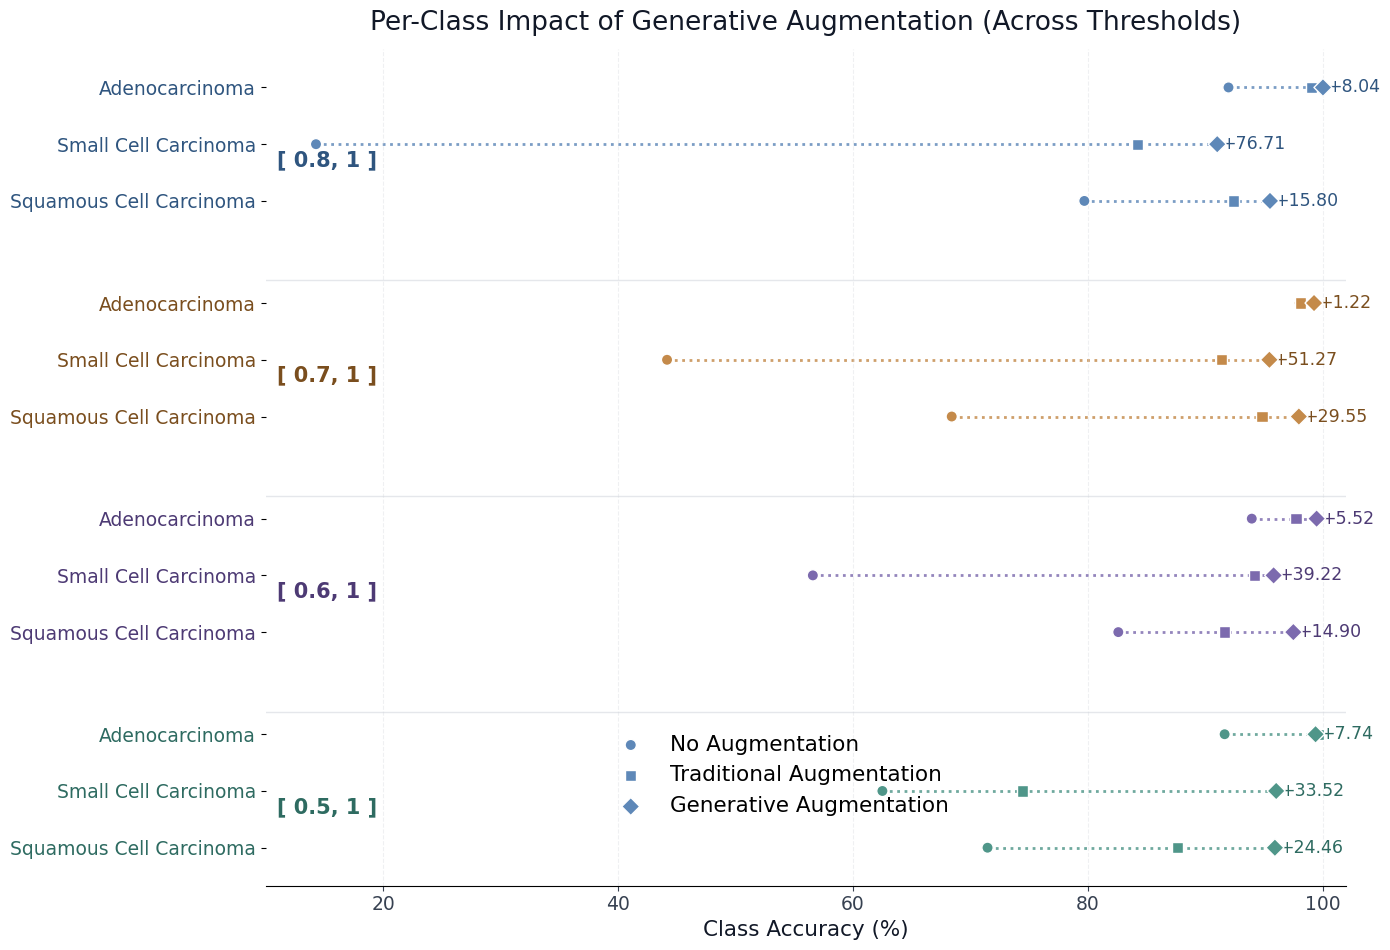

In [17]:
# per-class impact of generative augmentation
thresholds_cls = ['[ 0.8, 1 ]', '[ 0.7, 1 ]', '[ 0.6, 1 ]', '[ 0.5, 1 ]']
classes = ['Adenocarcinoma', 'Small Cell Carcinoma', 'Squamous Cell Carcinoma']

base_cls = np.array([
    [91.96, 14.29, 79.69],
    [98.02, 44.17, 68.40],
    [93.94, 56.58, 82.58],
    [91.63, 62.50, 71.45],
])
trad_cls = np.array([
    [99.02, 84.21, 92.38],
    [98.06, 91.38, 94.81],
    [97.70, 94.15, 91.63],
    [99.61, 74.42, 87.63],
])
gen_cls = np.array([
    [100.00, 91.00, 95.49],
    [99.24, 95.44, 97.95],
    [99.46, 95.80, 97.48],
    [99.37, 96.02, 95.91],
])

# build rows without repeating threshold text in every label
labels = []
base_flat, trad_flat, gen_flat = [], [], []
threshold_idx = []
for t_i in range(len(thresholds_cls)):
    for c_i, c in enumerate(classes):
        labels.append(c)
        base_flat.append(base_cls[t_i, c_i])
        trad_flat.append(trad_cls[t_i, c_i])
        gen_flat.append(gen_cls[t_i, c_i])
        threshold_idx.append(t_i)

base_flat = np.array(base_flat)
trad_flat = np.array(trad_flat)
gen_flat = np.array(gen_flat)
threshold_idx = np.array(threshold_idx)

# grouped y positions with gap between thresholds
group_gap = 0.8
y = []
for t_i in range(len(thresholds_cls)):
    start = t_i * (len(classes) + group_gap)
    for c_i in range(len(classes)):
        y.append(start + c_i)
y = np.array(y)

threshold_colors = ['#5E88B8', '#C48A4A', '#7C6AAE', '#4F9689']
threshold_text_colors = ['#2F557F', '#7A4E1E', '#4D3A74', '#2E6B61']
row_colors = [threshold_colors[i] for i in threshold_idx]
row_text_colors = [threshold_text_colors[i] for i in threshold_idx]
text_dark = '#111827'
grid_c = '#D1D5DB'

fig, ax = plt.subplots(figsize=(14.0, 9.6))

# dotted progression lines per row
for i in range(len(y)):
    ax.hlines(y[i], base_flat[i], gen_flat[i], color=row_colors[i], linewidth=2.0, linestyle=':', alpha=0.82, zorder=1)

# same threshold color across disease label + all three approach markers
ax.scatter(base_flat, y, s=66, c=row_colors, marker='o', edgecolor='white', linewidth=1.0, zorder=3, label='No Augmentation')
ax.scatter(trad_flat, y, s=66, c=row_colors, marker='s', edgecolor='white', linewidth=1.0, zorder=4, label='Traditional Augmentation')
ax.scatter(gen_flat, y, s=84, c=row_colors, marker='D', edgecolor='white', linewidth=1.0, zorder=5, label='Generative Augmentation')

# highlight generative impact against baseline
for i in range(len(y)):
    gain = gen_flat[i] - base_flat[i]
    ax.text(gen_flat[i] + 0.35, y[i], f'+{gain:.2f}', va='center', fontsize=12.5, color=row_text_colors[i], fontweight='medium')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=13.5)
for lbl, t_i in zip(ax.get_yticklabels(), threshold_idx):
    lbl.set_color(threshold_text_colors[t_i])

# add one threshold label per group 
for t_i, t in enumerate(thresholds_cls):
    group_rows = np.where(threshold_idx == t_i)[0]
    y_mid = y[group_rows].mean()
    ax.text(11.0, y_mid + 0.28, t, color=threshold_text_colors[t_i], fontsize=15.0, fontweight='bold', va='center')

# subtle separators between threshold groups
for t_i in range(1, len(thresholds_cls)):
    sep = t_i * (len(classes) + group_gap) - 0.4
    ax.axhline(sep, color='#E5E7EB', linewidth=1.0, zorder=0)

ax.invert_yaxis()
ax.set_xlim(10, 102)
ax.set_xlabel('Class Accuracy (%)', fontsize=15.5, color=text_dark)
ax.set_title('Per-Class Impact of Generative Augmentation (Across Thresholds)', fontsize=19, color=text_dark, pad=14)
ax.grid(axis='x', linestyle='--', alpha=0.34, color=grid_c)
ax.tick_params(axis='x', labelsize=13.5, colors='#374151')
ax.legend(frameon=False, fontsize=15.5, loc='lower left', bbox_to_anchor=(0.30, 0.06))

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

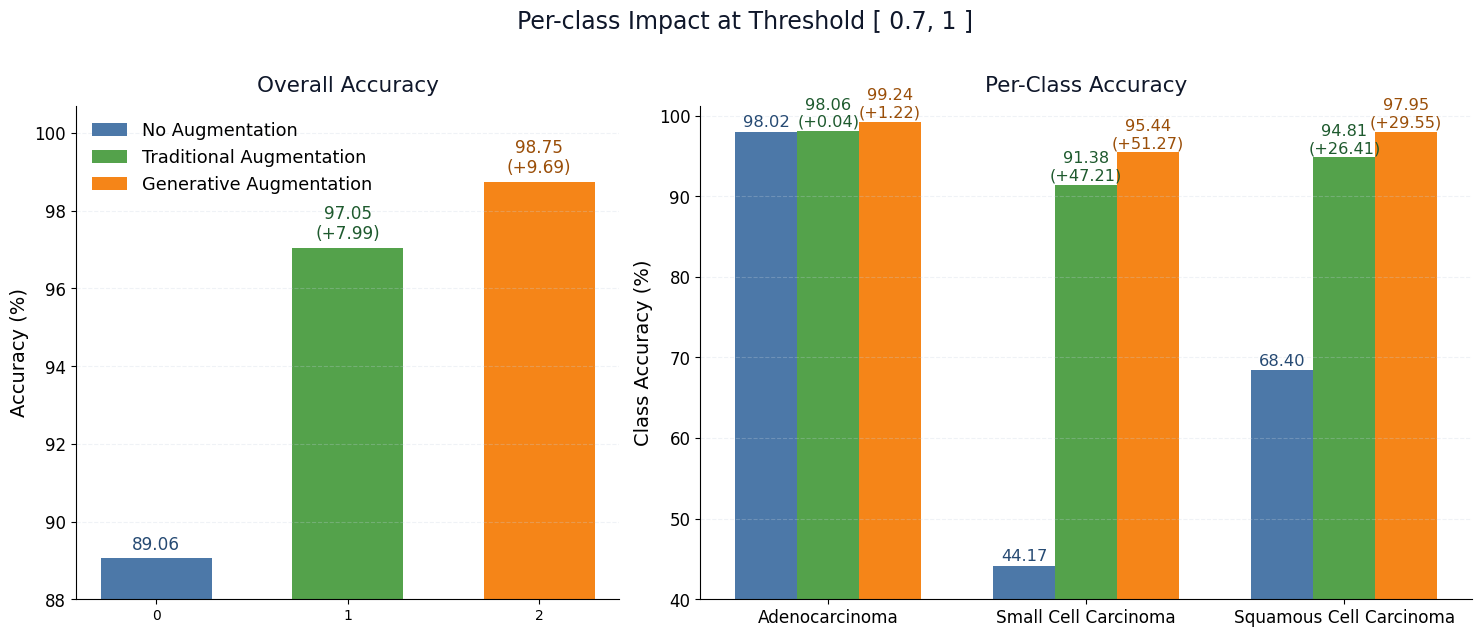

In [21]:
# threshold [ 0.7, 1]
threshold_label = '[ 0.7, 1 ]'
approaches = ['No Augmentation', 'Traditional Augmentation', 'Generative Augmentation']
classes = ['Adenocarcinoma', 'Small Cell Carcinoma', 'Squamous Cell Carcinoma']

# overall final accuracies
overall_base = 89.06
overall_trad = 97.05
overall_gen = 98.75

# per-class accuracies 
class_base = np.array([98.02, 44.17, 68.40])
class_trad = np.array([98.06, 91.38, 94.81])
class_gen = np.array([99.24, 95.44, 97.95])

# palette consistent with your notebook
c_base = '#4C78A8'
c_trad = '#54A24B'
c_gen = '#F58518'
text_dark = '#0F172A'
grid_c = '#C7D2E0'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15.0, 6.2), gridspec_kw={'width_ratios': [0.95, 1.35]})

# overall final accuracy at this threshold
overall_vals = np.array([overall_base, overall_trad, overall_gen])
x1 = np.arange(len(approaches))
bars1 = ax1.bar(x1, overall_vals, width=0.58, color=[c_base, c_trad, c_gen])

for j, b in enumerate(bars1):
    h = b.get_height()
    if j == 0:
        label = f'{h:.2f}'
        color = '#264A73'
    else:
        gain = h - overall_vals[0]
        label = f'{h:.2f}\n(+{gain:.2f})'
        color = '#1E5A2E' if j == 1 else '#9A4E08'
    ax1.text(b.get_x() + b.get_width() / 2, h + 0.12, label, ha='center', va='bottom', fontsize=12.2, color=color)

ax1.set_xticks(x1)
# ax1.set_xticklabels(approaches, fontsize=12.5)
ax1.set_ylim(88, 100.7)
ax1.set_ylabel('Accuracy (%)', fontsize=14.0)
ax1.set_title('Overall Accuracy', fontsize=15.5, color=text_dark, pad=10)
ax1.grid(axis='y', linestyle='--', alpha=0.28, color=grid_c)
ax1.legend(bars1, approaches, frameon=False, fontsize=12.8, loc='upper left')
ax1.tick_params(axis='y', labelsize=12.0)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# per-class detailed accuracies at this threshold
x2 = np.arange(len(classes))
bar_w = 0.24
b_base = ax2.bar(x2 - bar_w, class_base, width=bar_w, color=c_base, label='Baseline')
b_trad = ax2.bar(x2, class_trad, width=bar_w, color=c_trad, label='Traditional Aug')
b_gen = ax2.bar(x2 + bar_w, class_gen, width=bar_w, color=c_gen, label='Generative Aug')

for i in range(len(classes)):
    ax2.text(x2[i] - bar_w, class_base[i] + 0.20, f'{class_base[i]:.2f}', ha='center', va='bottom', fontsize=11.8, color='#264A73')
    ax2.text(x2[i], class_trad[i] + 0.20, f'{class_trad[i]:.2f}\n(+{class_trad[i] - class_base[i]:.2f})', ha='center', va='bottom', fontsize=11.6, color='#1E5A2E')
    ax2.text(x2[i] + bar_w, class_gen[i] + 0.20, f'{class_gen[i]:.2f}\n(+{class_gen[i] - class_base[i]:.2f})', ha='center', va='bottom', fontsize=11.6, color='#9A4E08')

ax2.set_xticks(x2)
ax2.set_xticklabels(classes, fontsize=12.2)
ax2.set_ylim(40, 101.2)
ax2.set_ylabel('Class Accuracy (%)', fontsize=14.0)
ax2.set_title('Per-Class Accuracy', fontsize=15.5, color=text_dark, pad=10)
ax2.grid(axis='y', linestyle='--', alpha=0.28, color=grid_c)
ax2.tick_params(axis='y', labelsize=12.0)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.suptitle(f'Per-class Impact at Threshold {threshold_label}', fontsize=17, color=text_dark, y=1.02)
fig.tight_layout()
plt.show()

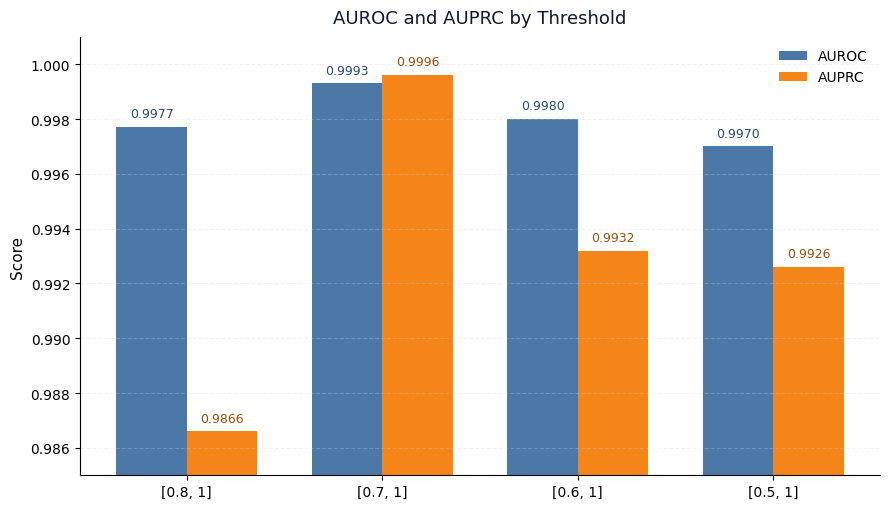

In [19]:
# AUROC / AUPRC by threshold
thresholds_auc = ['[0.8, 1]', '[0.7, 1]', '[0.6, 1]', '[0.5, 1]']
auroc = np.array([0.9977, 0.9993, 0.9980, 0.9970])
auprc = np.array([0.9866, 0.9996, 0.9932, 0.9926])

x = np.arange(len(thresholds_auc))
bar_w = 0.36

# consistent palette with previous plots
c_auroc = '#4C78A8'
c_auprc = '#F58518'
text_dark = '#0F172A'
grid_c = '#C7D2E0'

fig, ax = plt.subplots(figsize=(9.0, 5.2))

bars1 = ax.bar(x - bar_w / 2, auroc, width=bar_w, color=c_auroc, label='AUROC')
bars2 = ax.bar(x + bar_w / 2, auprc, width=bar_w, color=c_auprc, label='AUPRC')

for b in bars1:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 0.00025, f'{h:.4f}', ha='center', va='bottom', fontsize=9, color='#264A73')
for b in bars2:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 0.00025, f'{h:.4f}', ha='center', va='bottom', fontsize=9, color='#9A4E08')

ax.set_xticks(x)
ax.set_xticklabels(thresholds_auc, fontsize=10)
ax.set_ylim(0.985, 1.001)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('AUROC and AUPRC by Threshold', fontsize=13, color=text_dark, pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.28, color=grid_c)
ax.legend(frameon=False, fontsize=10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()